# SMS SPAM CLASSIFIER PROJECT

In [16]:
import numpy as np
import pandas as pd

In [17]:
df = pd.read_csv("./dataset/spam.csv", encoding="latin-1")

In [18]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1471,ham,Oh. U must have taken your REAL Valentine out ...,NaN,NaN,NaN
3408,ham,Whats that coming over the hill..... Is it a m...,NaN,NaN,NaN
352,ham,TODAY is Sorry day.! If ever i was angry with ...,NaN,NaN,NaN
689,spam,<Forwarded from 448712404000>Please CALL 08712...,NaN,NaN,NaN
5530,ham,I think that tantrum's finished so yeah I'll b...,NaN,NaN,NaN


In [19]:
df.shape

(5572, 5)

## Steps:
1. Data Cleaning
2. EDA
3. Text Preprossesing
4. Model Building
5. Evaluation
6. Improvent
7. Website
8. Deployment

## 1. DATA CLEANING

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [21]:
# Drop last 3 columns - Pretty much useless
df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"], inplace=True)

In [22]:
df.sample(5, random_state=4)

,v1,v2
4004,ham,", ow u dey.i paid 60,400thousad.i told u woul..."
2276,ham,Love you aathi..love u lot..
4498,spam,"SMS SERVICES. for your inclusive text credits,..."
3755,ham,Yes:)here tv is always available in work place..
111,ham,Going for dinner.msg you after.


In [23]:
# Renaming columns v1,v2 as they are not descriptive
df.rename(columns={"v1" : "target", "v2":"text"}, inplace=True)

In [24]:
df.sample(5)

,target,text
5018,ham,Great! How is the office today?
5399,ham,And he's apparently bffs with carly quick now
4761,ham,Me too! Have a lovely night xxx
4218,ham,Anything lor if they all go then i go lor...
1215,ham,that would be good Û_ I'll phone you tomo lun...


In [25]:
# We need integer target values so lets transform those
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [26]:
df["target"] = encoder.fit_transform(df["target"])

In [27]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [28]:
# Missing values check
df.isnull().sum()

target    0
text      0
dtype: int64

In [29]:
# Check for duplicate values
df.duplicated().sum()

np.int64(403)

In [30]:
# Remove duplicate
df.drop_duplicates(keep='first', inplace=True)

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.shape

(5169, 2)

## 2. EDA

In [33]:
# Check percent of data that is spam and that is ham
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

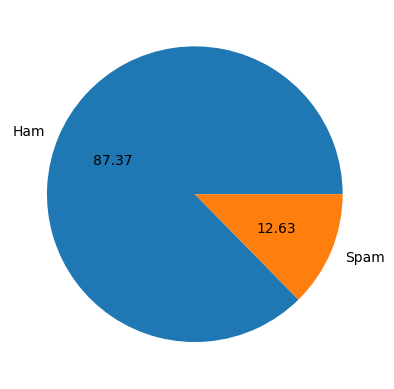

In [34]:
# we could create a pie chart to show the balance
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels = ["Ham","Spam"], autopct="%0.2f")
plt.show()

- Data is Imbalanced

In [35]:
import nltk

In [36]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bhand\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\bhand\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bhand\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

We will create new columns in df
1. Number of characters in the text
2. Number of words in the sms
3. Number of sentenses in the sms

In [37]:
# 1
df['num_characters'] = df['text'].apply(len)

In [38]:
df.head(5)

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [39]:
# 2
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [40]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [41]:
# 3
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))


In [42]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [43]:
# Overall Analysis
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [44]:
# Comparing only Ham messages
df[df['target'] == 0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [45]:
df[df['target'] == 1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [46]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

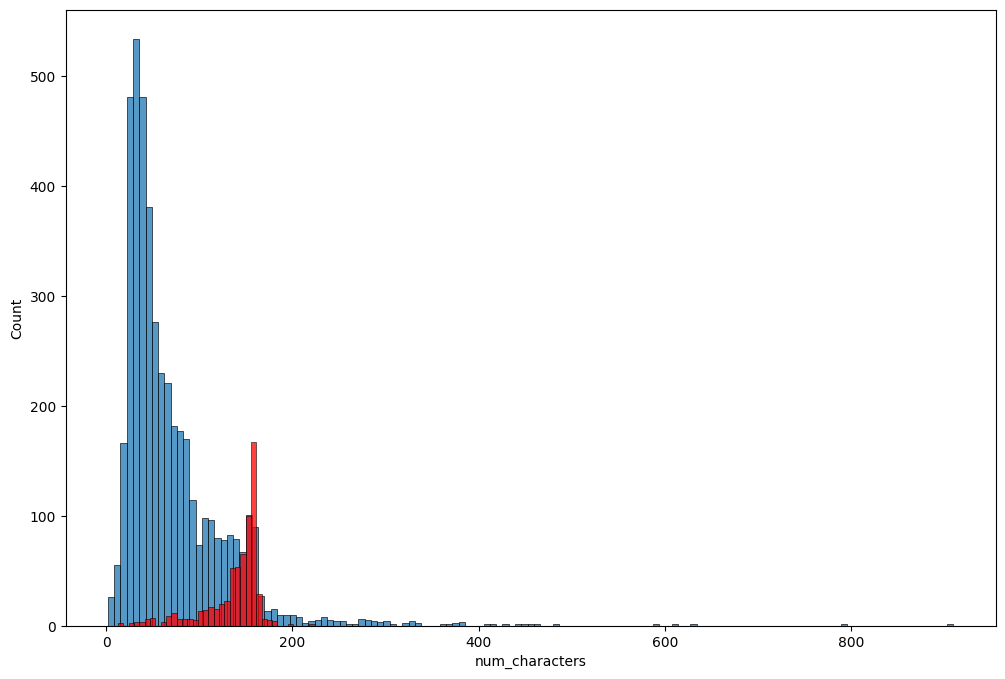

In [47]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'], color='red')

<Axes: xlabel='num_words', ylabel='Count'>

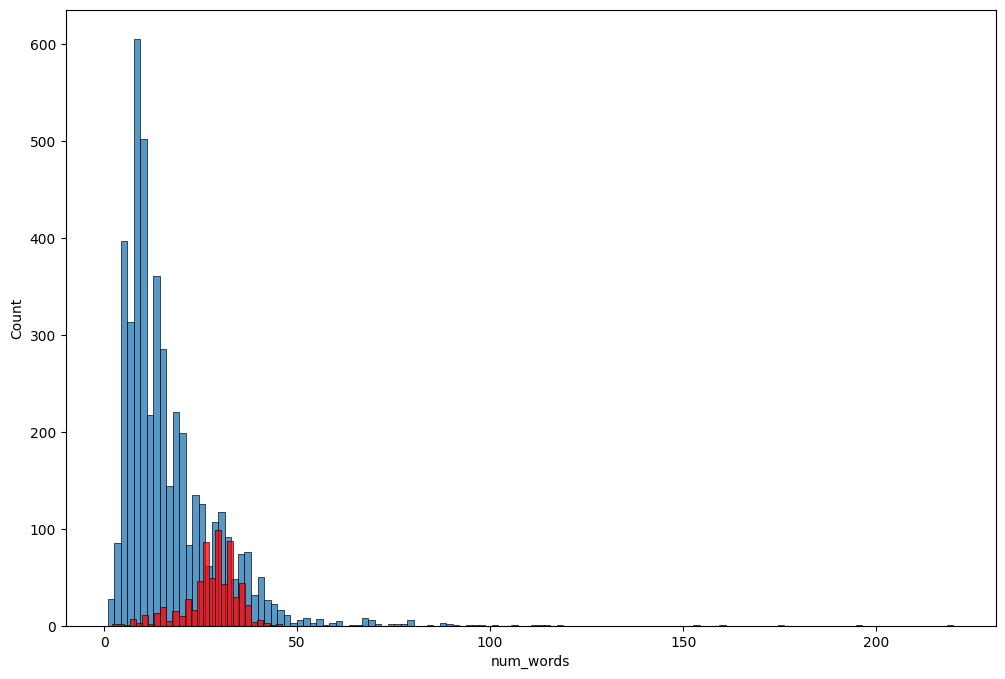

In [48]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'], color='red')

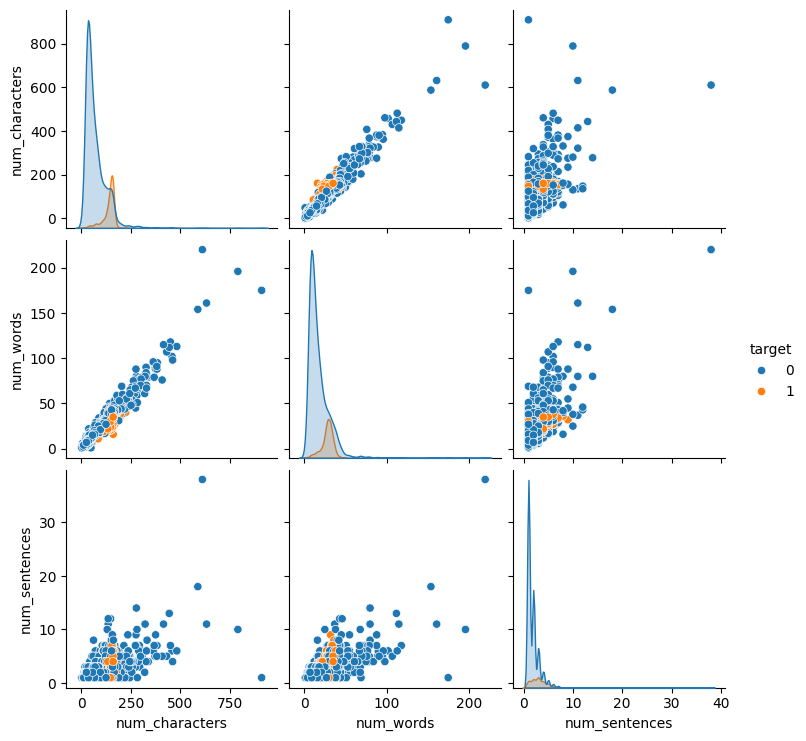

In [49]:
sns.pairplot(df,hue='target')

In [50]:
df[["target","num_characters","num_words","num_sentences"]].corr()

,target,num_characters,num_words,num_sentences
target,1.000000,0.384717,0.262912,0.263939
num_characters,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

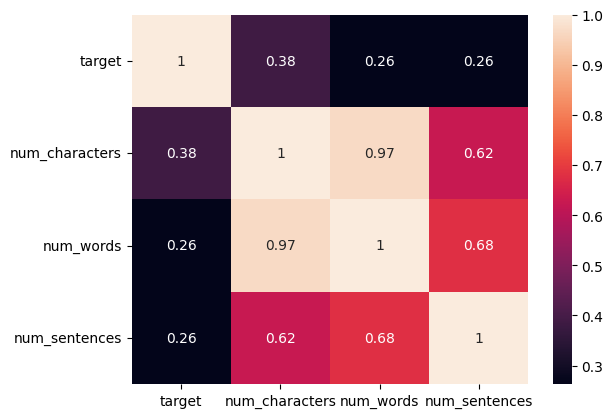

In [51]:
sns.heatmap(df[["target","num_characters","num_words","num_sentences"]].corr(), annot=True)

- From here we can know that num_sentences, num_words, num_chars have a high correlation with each other. When modelling we cant pass all the 3 columns as input due to multi-collinearity so we have to choose 1.
- So what do we choose? The one that has the highest correlation with target! So that is num_characters

## 3. Data Preprocessing
- Lower case
- Tokenization
- Removing special chars
- Removing stop words and punctuation
- Stemming

In [52]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [53]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [54]:
# Stemming -> This is the process of reducing a word to its root form. For example, "running" would be reduced to "run". This can help in reducing the dimensionality of the data and improving the performance of machine learning models.
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('dancing')

'danc'

In [ ]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return  " ".join(y)

In [56]:
transform_text("I loved the youtube lectures on Machine Learning. How about you?")

'love youtub lectur machin learn'

In [57]:
df['transformed_text'] = df['text'].apply(transform_text)

In [58]:
df.sample(5)

,target,text,num_characters,num_words,num_sentences,transformed_text
1994,0,Have you been practising your curtsey?,38,7,1,practis curtsey
2946,0,Leave it. U will always be ignorant.,36,9,2,leav u alway ignor
2583,0,"Goodmorning, today i am late for 1hr.",37,9,1,goodmorn today late 1hr
392,0,Morning only i can ok.,22,6,1,morn ok
5441,0,"By the way, make sure u get train to worc fore...",90,21,2,way make sure u get train worc foreg street sh...


## Spam Wordcloud

In [59]:
#word cloud of spam msgs
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [60]:
spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=' '))

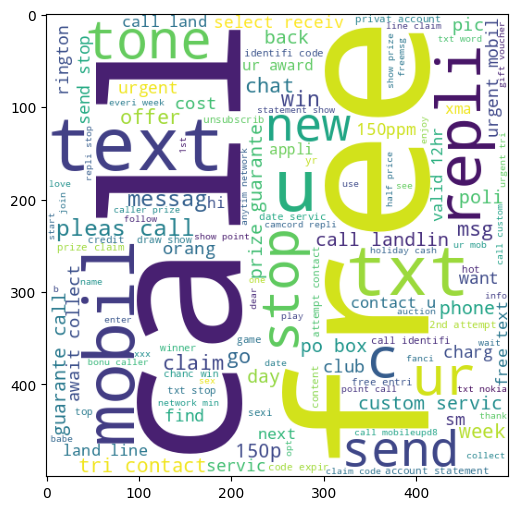

In [61]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

## Ham WordCloud

In [62]:

ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=' '))

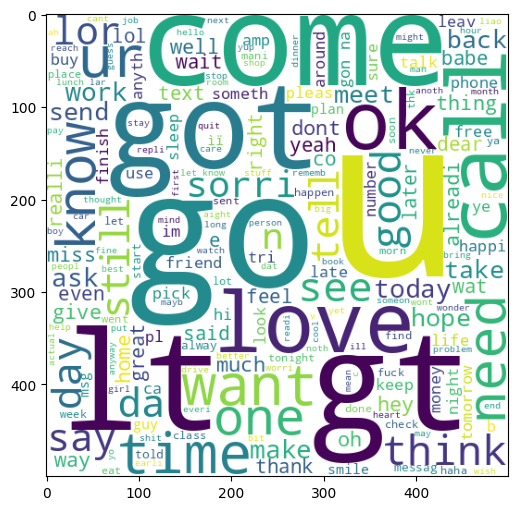

In [63]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [64]:
# Top 30 spam words
spam_corpus = []
for msg in df[df['target']==1]["transformed_text"].tolist():
    for word in msg.split(" "):
        spam_corpus.append(word)

len(spam_corpus)

9939

In [65]:
from collections import Counter
spam_df = pd.DataFrame(Counter(spam_corpus).most_common(30))
spam_df

,0,1
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


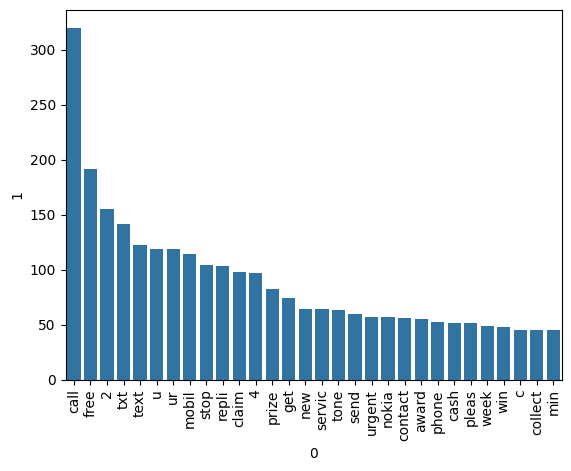

In [66]:
sns.barplot(x=spam_df[0],y=spam_df[1])
plt.xticks(rotation='vertical')
plt.show()

In [67]:
# Top 30 Ham Words
ham_corpus = []
for msg in df[df["target"]==0]["transformed_text"].tolist():
    for word in msg.split():
        ham_corpus.append(word)

len(ham_corpus)

35404

In [68]:
from collections import Counter
Counter(ham_corpus) # This is an object but .most_common(30) is a list so u can pass it into Dataframe
ham_df = pd.DataFrame(Counter(ham_corpus).most_common(30))

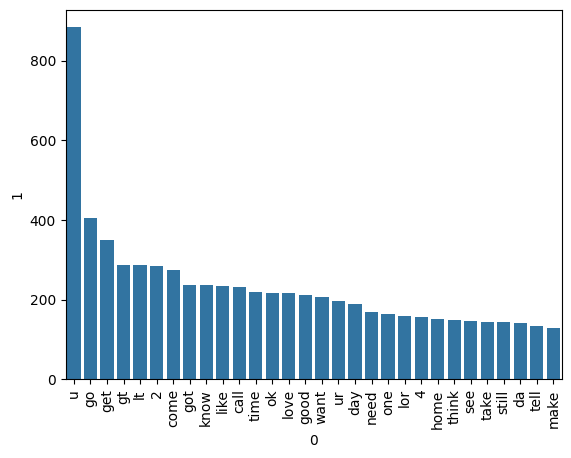

In [69]:
sns.barplot(x=ham_df[0],y=ham_df[1])
plt.xticks(rotation="vertical")
plt.show()

# 4. Model Building

In [70]:
# We will first use Naive Bayes Algorithm since it usually performs best on Textual Data. Our input is the transformed text, a text data and output is numerical target
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()


In [71]:
df["transformed_text"].shape

(5169,)

In [72]:
myX = set()
for msg in df["transformed_text"]:
    for word in msg.split():
        myX.add(word)

len(myX)

6736

In [73]:
# We can now understand where the shape of this transformed vectotr is coming from
X = cv.fit_transform(df["transformed_text"]).toarray()
X.shape

(5169, 6708)

In [74]:
y = df["target"].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [75]:
from sklearn.model_selection import train_test_split

In [76]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [77]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [78]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [79]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8800773694390716
[[792 104]
 [ 20 118]]
0.5315315315315315


In [80]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9642166344294004
[[871  25]
 [ 12 126]]
0.8344370860927153


In [81]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


In [82]:
X2 = tfidf.fit_transform(df["transformed_text"]).toarray()
X2.shape

(5169, 6708)

In [83]:
X_train,X_test,y_train,y_test = train_test_split(X2, y, test_size=0.2, random_state=2)

In [84]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8762088974854932
[[793 103]
 [ 25 113]]
0.5231481481481481


In [85]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9593810444874274
[[896   0]
 [ 42  96]]
1.0


In [86]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


- Even though the accuracy score of binomial Naive Bayes model is higher, we will select multinomial naive base because in textual data, precision score is usually the important metric to consider and mnb has 1 via the TfidfVectorizer() on X

In [87]:
## Chosen Tfidf with MultinomialNB

In [88]:
# Now we will try the rest of the classification algorithms to see if we can do better than MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier
%pip install xgboost
from xgboost import XGBClassifier

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [89]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5, random_state=2)
lrc = LogisticRegression(solver='liblinear',penalty='l1', random_state=2)
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)


In [90]:
clfs = {
    "SVC": svc,
    "KNC": knc,
    "MNB": mnb,
    "DTC": dtc,
    "LRC": lrc,
    "RFC": rfc,
    "ABC": abc,
    "GBDT": gbdt,
    "ETC": etc,
    "BC": bc,
    "XGB": xgb
}

In [91]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    return accuracy, precision

In [166]:
train_classifier(svc, X_train, y_train, X_test, y_test)

(0.9729206963249516, 0.9741379310344828)

In [170]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    print(f"For {name} Accuracy: {current_accuracy} and Precision: {current_precision}")
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For SVC Accuracy: 0.9729206963249516 and Precision: 0.9741379310344828
For KNC Accuracy: 0.9003868471953579 and Precision: 1.0
For MNB Accuracy: 0.9593810444874274 and Precision: 1.0
For DTC Accuracy: 0.9352030947775629 and Precision: 0.8380952380952381


C:\Users\bhand\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\bhand\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For LRC Accuracy: 0.9516441005802708 and Precision: 0.94
For RFC Accuracy: 0.971953578336557 and Precision: 1.0
For ABC Accuracy: 0.9245647969052224 and Precision: 0.8409090909090909
For GBDT Accuracy: 0.9526112185686654 and Precision: 0.9238095238095239
For ETC Accuracy: 0.9729206963249516 and Precision: 0.9824561403508771
For BC Accuracy: 0.9584139264990329 and Precision: 0.8625954198473282
For XGB Accuracy: 0.9748549323017408 and Precision: 0.9516129032258065


In [171]:
performance_df = pd.DataFrame({"Algorithm": clfs.keys(), "Accuracy": accuracy_scores, "Precision": precision_scores}).sort_values("Precision", ascending=False)
performance_df

,Algorithm,Accuracy,Precision
1,KNC,0.900387,1.000000
2,MNB,0.959381,1.000000
5,RFC,0.971954,1.000000
8,ETC,0.972921,0.982456
0,SVC,0.972921,0.974138
10,XGB,0.974855,0.951613
4,LRC,0.951644,0.940000
7,GBDT,0.952611,0.923810
9,BC,0.958414,0.862595
6,ABC,0.924565,0.840909


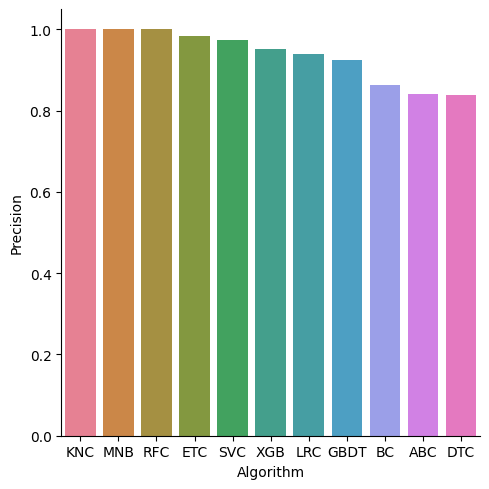

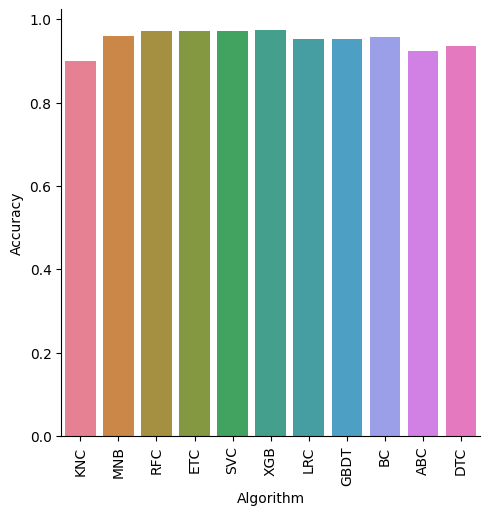

In [177]:
sns.catplot(x="Algorithm", y="Precision", hue="Algorithm", data=performance_df, kind="bar", height=5)
sns.catplot(x="Algorithm", y="Accuracy", hue="Algorithm", data=performance_df, kind="bar", height=5)
plt.xticks(rotation=90)
plt.show()

## Model Improve
### 1. Change the number of max_feature parameter of Tfidf
### 2. Scale X. Using minmax Scalar

In [ ]:
# Max Parameter Tuning for MultinomialNB
# Final result, It improved alittle accuracy of mnb from 0.95 to 0.97
#Other models did not improve with parameter tuning

In [ ]:
# Scaling strateg accually decreased the accurary for all models so I will not be using it. I think it is because of the nature of the data and the fact that we are using Naive Bayes which is not sensitive to feature scaling.

# 6. Voting Classifier
## These are combinations of my best performing algorithms

In [97]:
svc = SVC(kernel='sigmoid', gamma=1.0, probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [98]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)], voting='soft')

In [99]:
voting.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('svm', ...), ('nb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'sigmoid'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1.0
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [100]:
y_pred = voting.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(precision_score(y_test, y_pred))


0.9787234042553191
[[896   0]
 [ 22 116]]
1.0


In [101]:
# Applying stacking classifier to see if we can improve the performance of our model. Stacking is a technique where we combine the predictions of multiple models to create a new model that is more accurate than any of the individual models. We will use the same base models as before and use Random Forest as the meta model to combine the predictions of the base models.
from sklearn.ensemble import StackingClassifier

In [102]:
clf = StackingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)], final_estimator=RandomForestClassifier())

In [103]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(precision_score(y_test, y_pred))

0.9796905222437138
[[889   7]
 [ 14 124]]
0.9465648854961832


# Pipeline Creation For Model Deployment

In [ ]:
# We will use the voting classifier as our final model since it has the best precision score. We will save this model using pickle so that we can use it later for prediction on new data.

1. Whenever we get a new email, the first step will be to transform the email
-> Remember we had make the transform_text function that we used to transform text
2. Vectorize the newly transformed email
3. Apply the algorithm

In [105]:
import pickle
pickle.dump(transform_text, open("transform.pkl", "wb"))
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))
pickle.dump(voting, open("model.pkl", "wb"))